In [1]:
from pathlib import Path
from tensorboard.backend.event_processing import event_accumulator
import matplotlib.pyplot as plt

In [7]:
def plot_metrics(path):
    # Загружаем логи
    ea = event_accumulator.EventAccumulator(path)  # путь к логам
    ea.Reload()

    # Смотрим доступные теги
    print(ea.Tags()['scalars'])  # например: ['train/loss', 'val/loss']

    # Извлекаем данные
    loss = ea.Scalars('train/loss')
    steps = [x.step for x in loss]
    values = [x.value for x in loss]

    # Рисуем
    plt.figure(figsize=(10, 5))
    plt.plot(steps, values, label='Train Loss')
    plt.xlabel('Step')
    plt.ylabel('Loss')
    plt.title('Training Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

In [10]:
def plot_metrics(path, keys=["train/loss"]):
    ea = event_accumulator.EventAccumulator(path)
    ea.Reload()

    n = len(keys)
    cols = 2
    rows = (n + 1) // 2

    fig, axes = plt.subplots(rows, cols, figsize=(12, 5 * rows))
    axes = axes.flatten() if n > 1 else [axes]

    for i, key in enumerate(keys):
        scalars = ea.Scalars(key)
        steps = [x.step for x in scalars]
        values = [x.value for x in scalars]

        axes[i].plot(steps, values, label=key)
        axes[i].set_xlabel('Step')
        axes[i].set_ylabel('Value')
        axes[i].set_title(key)
        axes[i].legend()
        axes[i].grid(True)

    # Скрываем лишние ячейки, если ключей нечётное количество
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()

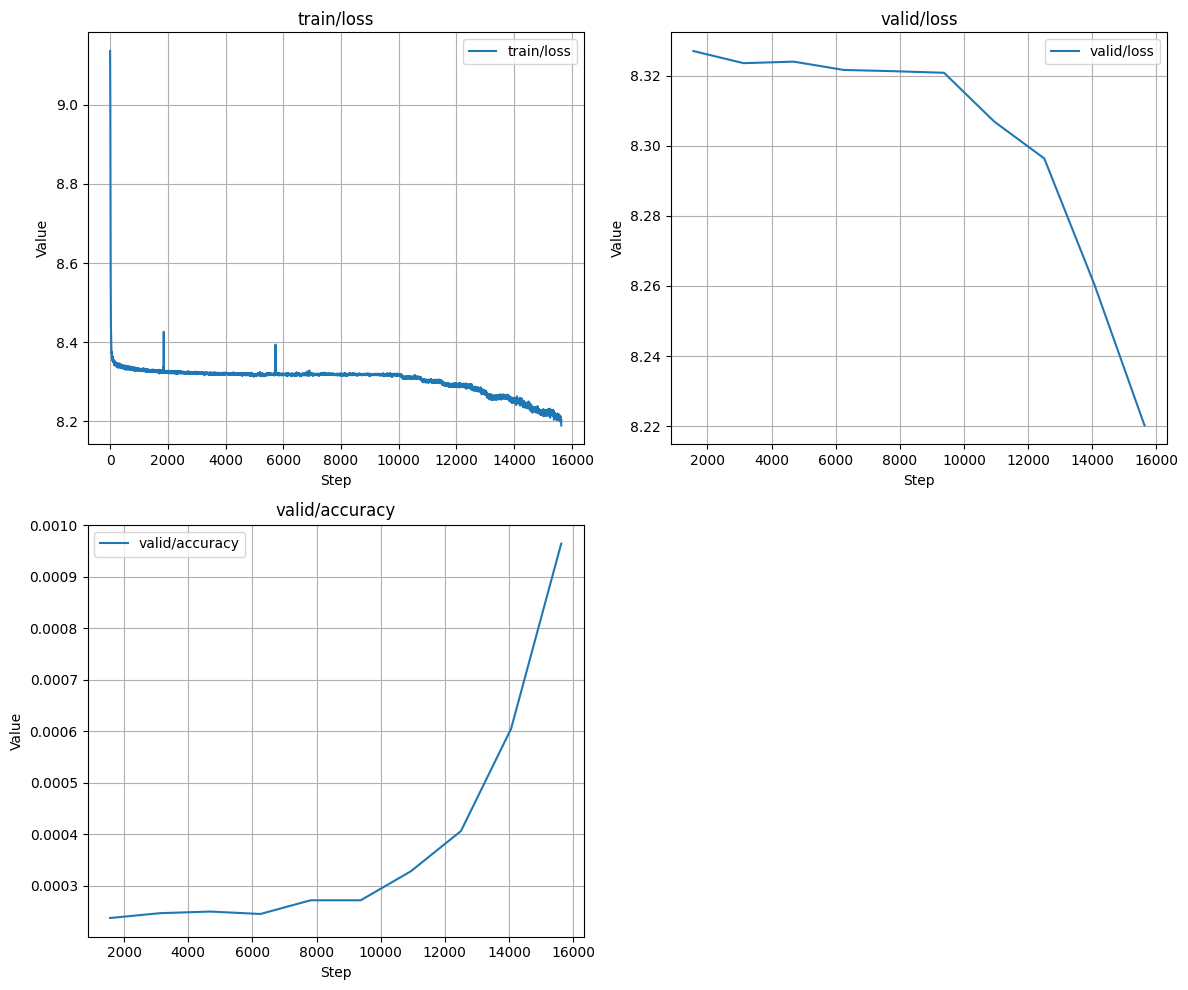

In [13]:
plot_metrics(
    "/home/needpetrov/projects/zoology/runs/Mamba_4_layers__lr_0.0003__difficulty_64/default/events.out.tfevents.1777859200.butch.3361006.2",
    keys=["train/loss", "valid/loss", "valid/accuracy"],
)